In [80]:
# ------------------------------------------------------------
# 경고 제거
# ------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# ============================================================
# 전자상거래 성과 분석 대시보드
# Google Colab 최종버전
# ============================================================

!apt-get -qq update
!apt-get -qq install fonts-nanum
!pip -q install openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from google.colab import files

# ============================================================
# 한글 폰트 설정
# ============================================================

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fm.fontManager.addfont(font_path)

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


Saving merged_aircon_power.xlsx to merged_aircon_power (2).xlsx


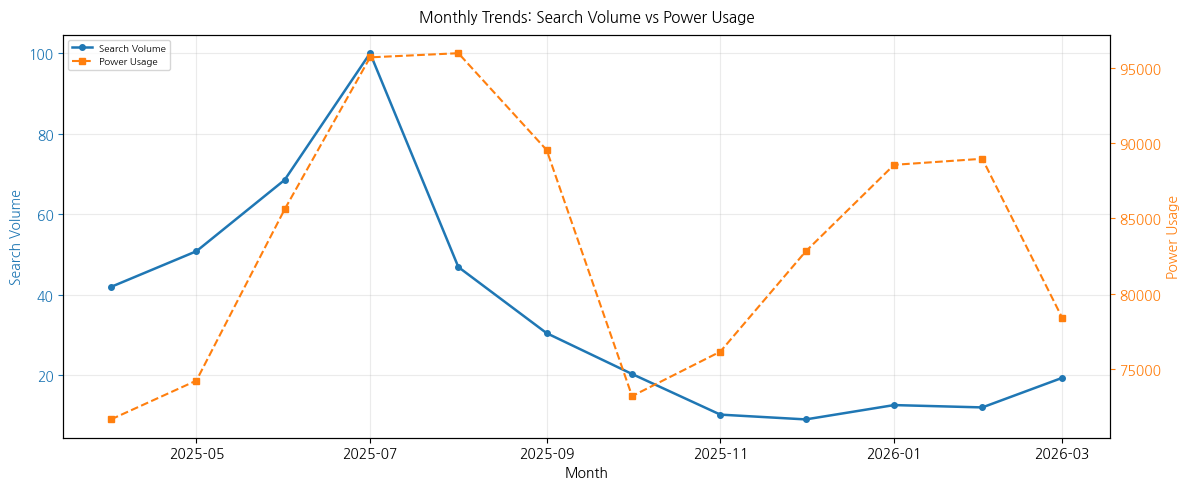

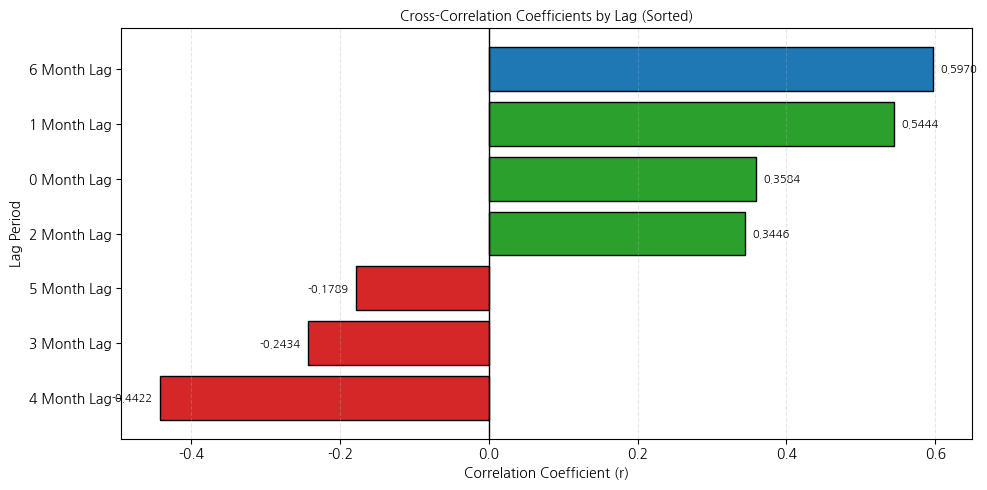


Lag Correlation Result
   Lag  Correlation  Strength
0    0       0.3584      Weak
1    1       0.5444  Moderate
2    2       0.3446      Weak
3    3      -0.2434      Weak
4    4      -0.4422  Moderate
5    5      -0.1789      Weak
6    6       0.5970  Moderate

Best Lag
Lag : 6 Month
Correlation : 0.5970

Conclusion
Search Volume leads Power Usage by approximately 6 month(s), showing the strongest correlation (0.5970).


In [90]:
# ============================================================
# 에어컨 검색량 vs 전력사용량 시차 상관분석
# Google Colab
# month | search_volume | power_usage
# ============================================================

!apt-get -qq install fonts-nanum > /dev/null

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from google.colab import files

# ============================================================
# 한글 폰트 설정
# ============================================================

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()

plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

# ============================================================
# 파일 업로드
# ============================================================

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)

# ============================================================
# 데이터 전처리
# ============================================================

df['month'] = pd.to_datetime(df['month'])
df = df.sort_values('month').reset_index(drop=True)

# ============================================================
# 1. 월별 추이 그래프
# (사용자 예시 스타일)
# ============================================================

fig, ax1 = plt.subplots(figsize=(12, 5))

line1 = ax1.plot(
    df['month'],
    df['search_volume'],
    marker='o',
    markersize=4,
    linewidth=1.8,
    color='#1f77b4',
    label='Search Volume'
)

ax1.set_ylabel(
    'Search Volume',
    color='#1f77b4',
    fontsize=10,
    fontweight='bold'
)

ax1.tick_params(
    axis='y',
    colors='#1f77b4'
)

ax1.grid(
    True,
    linestyle='-',
    alpha=0.25
)

ax2 = ax1.twinx()

line2 = ax2.plot(
    df['month'],
    df['power_usage'],
    marker='s',
    markersize=4,
    linewidth=1.5,
    linestyle='--',
    color='#ff7f0e',
    label='Power Usage'
)

ax2.set_ylabel(
    'Power Usage',
    color='#ff7f0e',
    fontsize=10,
    fontweight='bold'
)

ax2.tick_params(
    axis='y',
    colors='#ff7f0e'
)

plt.title(
    'Monthly Trends: Search Volume vs Power Usage',
    fontsize=11,
    fontweight='bold',
    pad=10
)

ax1.set_xlabel('Month')

plt.xticks(
    rotation=45,
    fontsize=8
)

lines = line1 + line2
labels = [l.get_label() for l in lines]

ax1.legend(
    lines,
    labels,
    loc='upper left',
    fontsize=7,
    frameon=True
)

plt.tight_layout()
plt.show()

# ============================================================
# 2. 시차별 상관계수 계산
# ============================================================

results = []

for lag in range(7):

    corr = (
        df['search_volume']
        .corr(
            df['power_usage'].shift(-lag)
        )
    )

    results.append([lag, corr])

corr_df = pd.DataFrame(
    results,
    columns=['Lag', 'Correlation']
)

# ============================================================
# 3. 최고 상관계수 찾기
# ============================================================

best_idx = corr_df['Correlation'].abs().idxmax()

best_lag = int(
    corr_df.loc[best_idx, 'Lag']
)

best_corr = (
    corr_df.loc[best_idx, 'Correlation']
)

# ============================================================
# 4. 시차별 상관계수 그래프
# (사용자 예시 스타일)
# ============================================================

plot_df = corr_df.copy()

plot_df = plot_df.sort_values(
    'Correlation',
    ascending=True
)

colors = []

for _, row in plot_df.iterrows():

    if row['Lag'] == best_lag:
        colors.append('#1f77b4')
    elif row['Correlation'] >= 0:
        colors.append('#2ca02c')
    else:
        colors.append('#d62728')

plt.figure(figsize=(10, 5))

bars = plt.barh(
    plot_df['Lag'].astype(str) + ' Month Lag',
    plot_df['Correlation'],
    color=colors,
    edgecolor='black'
)

plt.axvline(
    0,
    color='black',
    linewidth=1
)

for bar in bars:

    width = bar.get_width()

    if width >= 0:

        plt.text(
            width + 0.01,
            bar.get_y() + bar.get_height()/2,
            f'{width:.4f}',
            va='center',
            fontsize=8
        )

    else:

        plt.text(
            width - 0.01,
            bar.get_y() + bar.get_height()/2,
            f'{width:.4f}',
            va='center',
            ha='right',
            fontsize=8
        )

plt.title(
    'Cross-Correlation Coefficients by Lag (Sorted)',
    fontsize=10,
    fontweight='bold'
)

plt.xlabel(
    'Correlation Coefficient (r)'
)

plt.ylabel(
    'Lag Period'
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.show()

# ============================================================
# 5. 결과 출력
# ============================================================

summary = corr_df.copy()

summary['Strength'] = summary['Correlation'].abs().apply(
    lambda x:
    'Very Strong' if x >= 0.8 else
    'Strong' if x >= 0.6 else
    'Moderate' if x >= 0.4 else
    'Weak'
)

print("\n==============================")
print("Lag Correlation Result")
print("==============================")
print(summary.round(4))

print("\n==============================")
print("Best Lag")
print("==============================")
print(f"Lag : {best_lag} Month")
print(f"Correlation : {best_corr:.4f}")

print("\n==============================")
print("Conclusion")
print("==============================")
print(
    f"Search Volume leads Power Usage by approximately "
    f"{best_lag} month(s), showing the strongest "
    f"correlation ({best_corr:.4f})."
)